SECTION 0


Setup (Load libraries and configure environment)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from collections import defaultdict

from tqdm import tqdm

Dataset Setup (Define dataset files)

In [ ]:
files = [
    "combined_data_1.txt",
    "combined_data_2.txt",
    "combined_data_3.txt",
    "combined_data_4.txt"
]

SECTION 1

Interaction Landscape
(Understanding the scale of the recommendation problem)

How large and sparse is the Netflix user-item interaction network?

In [ ]:
TOTAL_USERS = 480189

TOTAL_MOVIES = 17770

TOTAL_RATINGS = 100480507

print(
    f"Users   : {TOTAL_USERS:,}"
)

print(
    f"Movies  : {TOTAL_MOVIES:,}"
)

print(
    f"Ratings : {TOTAL_RATINGS:,}"
)

Users   : 480,189
Movies  : 17,770
Ratings : 100,480,507


In [ ]:
sparsity = (
    1 -
    TOTAL_RATINGS /
    (
        TOTAL_USERS *
        TOTAL_MOVIES
    )
)

print(
    f"Sparsity : {sparsity:.4%}"
)

Sparsity : 98.8224%


In [ ]:
density = 1 - sparsity

print(
    f"Density : {density:.4%}"
)

Density : 1.1776%


Observation - The Netflix interaction matrix is extremely sparse, with only a small fraction of all possible user–movie interactions observed.

SECTION 2

Rating Behaviour (Understanding the feedback signal)

How are ratings distributed across the 1-5 scale?

In [ ]:
rating_counts = Counter()

for file in files:

    with open(file, "r") as f:

        for line in tqdm(
            f,
            desc=file
        ):

            line = line.strip()

            if not line.endswith(":"):

                rating = int(
                    line.split(",")[1]
                )

                rating_counts[
                    rating
                ] += 1

combined_data_1.txt: 24058263it [00:38, 622555.56it/s]
combined_data_2.txt: 26982302it [00:41, 646517.45it/s]
combined_data_3.txt: 22605786it [00:34, 663105.18it/s]
combined_data_4.txt: 26851926it [00:37, 717363.74it/s]


In [ ]:
rating_df = pd.DataFrame({
    "rating":
    sorted(
        rating_counts.keys()
    ),

    "count":
    [
        rating_counts[r]
        for r in sorted(
            rating_counts.keys()
        )
    ]
})

rating_df

,rating,count
0,1,4617990
1,2,10132080
2,3,28811247
3,4,33750958
4,5,23168232


In [ ]:
rating_df["percentage"] = (
    rating_df["count"]
    /
    rating_df["count"].sum()
) * 100

rating_df

,rating,count,percentage
0,1,4617990,4.595906
1,2,10132080,10.083627
2,3,28811247,28.673469
3,4,33750958,33.589558
4,5,23168232,23.057439


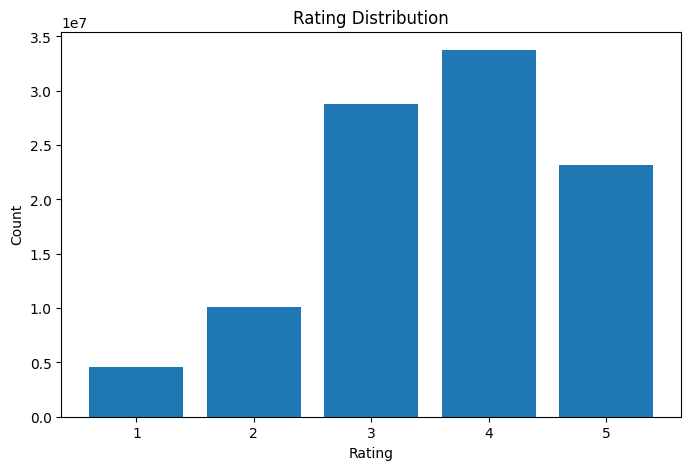

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    rating_df["rating"],
    rating_df["count"]
)

plt.title(
    "Rating Distribution"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Count"
)

plt.show()

Observation - Higher ratings occur much more frequently than lower ratings, suggesting users generally provide positive feedback.

SECTION 3

User Behaviour (Understanding user activity patterns)

How active are users and how severe is the cold-start problem?

In [ ]:
user_counts = Counter()

for file in files:

    with open(file, "r") as f:

        for line in tqdm(
            f,
            desc=file
        ):

            line = line.strip()

            if not line.endswith(":"):

                user_id = int(
                    line.split(",")[0]
                )

                user_counts[
                    user_id
                ] += 1

combined_data_1.txt: 24058263it [00:51, 465714.83it/s]
combined_data_2.txt: 26982302it [00:51, 524383.73it/s]
combined_data_3.txt: 22605786it [00:47, 480807.83it/s]
combined_data_4.txt: 26851926it [00:54, 496122.78it/s]


In [ ]:
user_ratings = np.array(
    list(
        user_counts.values()
    )
)

pd.Series(
    user_ratings
).describe()

,0
count,480189.000000
mean,209.251997
std,302.339155
min,1.000000
25%,39.000000
50%,96.000000
75%,259.000000
max,17653.000000


In [ ]:
for p in [
    25,
    50,
    75,
    90,
    95,
    99
]:

    print(
        f"{p}th percentile:",
        np.percentile(
            user_ratings,
            p
        )
    )

25th percentile: 39.0
50th percentile: 96.0
75th percentile: 259.0
90th percentile: 541.0
95th percentile: 779.0
99th percentile: 1390.0


In [ ]:
cold_start = (
    user_ratings < 10
).sum()

print(
    "Users with fewer than 10 ratings:",
    round(
        100 *
        cold_start /
        len(user_ratings),
        2
    ),
    "%"
)

Users with fewer than 10 ratings: 3.42 %


In [ ]:
for threshold in [5,10,20,50]:

    pct = (
        (user_ratings < threshold).sum()
        /
        len(user_ratings)
    ) * 100

    print(
        f"< {threshold} ratings:",
        round(pct,2),
        "%"
    )

< 5 ratings: 1.5 %
< 10 ratings: 3.42 %
< 20 ratings: 10.54 %
< 50 ratings: 31.86 %


Observation - User activity is highly skewed, with a small number of users contributing substantially more ratings than the majority.

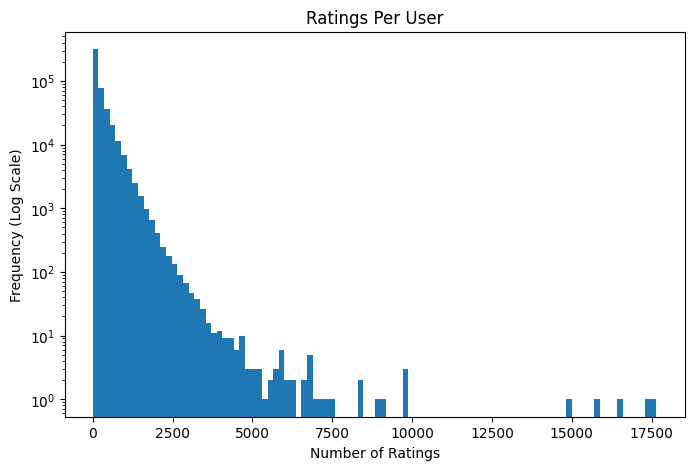

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    user_ratings,
    bins=100,
    log=True
)

plt.title(
    "Ratings Per User"
)

plt.xlabel(
    "Number of Ratings"
)

plt.ylabel(
    "Frequency (Log Scale)"
)

plt.show()

Observation - User activity is highly uneven. Most users provide relatively few ratings, while a small number of power users contribute a large share of interactions.

User Activity CDF plot

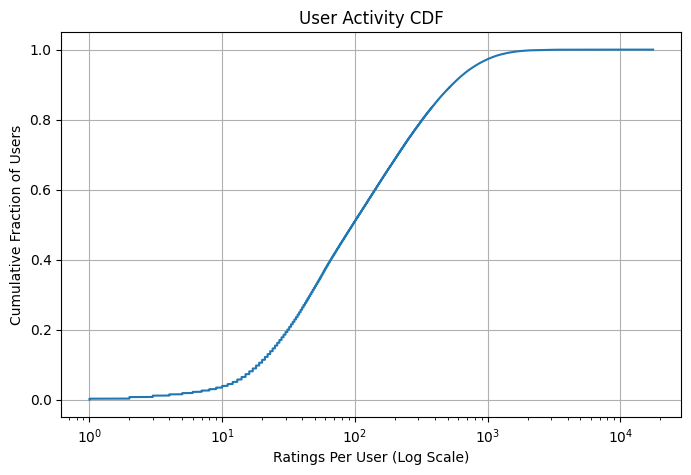

In [ ]:
sorted_users = np.sort(user_ratings)

cdf = np.arange(
    len(sorted_users)
) / len(sorted_users)

plt.figure(figsize=(8,5))

plt.plot(
    sorted_users,
    cdf
)

plt.xscale("log")

plt.xlabel(
    "Ratings Per User (Log Scale)"
)

plt.ylabel(
    "Cumulative Fraction of Users"
)

plt.title(
    "User Activity CDF"
)

plt.grid(True)

plt.show()

Observation - Most users have relatively moderate activity levels, while a small fraction of users are extremely active.

SECTION 4

Movie Behaviour (Understanding item popularity patterns)

How much attention does each movie receive?

In [ ]:
movie_counts = Counter()

for file in files:

    current_movie = None

    with open(file, "r") as f:

        for line in tqdm(
            f,
            desc=file
        ):

            line = line.strip()

            if line.endswith(":"):

                current_movie = int(
                    line[:-1]
                )

            else:

                movie_counts[
                    current_movie
                ] += 1

combined_data_1.txt: 24058263it [00:22, 1074605.24it/s]
combined_data_2.txt: 26982302it [00:26, 1016049.20it/s]
combined_data_3.txt: 22605786it [00:22, 1022414.61it/s]
combined_data_4.txt: 26851926it [00:26, 1024949.60it/s]


In [ ]:
movie_ratings = np.array(
    list(
        movie_counts.values()
    )
)

pd.Series(
    movie_ratings
).describe()

,0
count,17770.000000
mean,5654.502364
std,16909.673269
min,3.000000
25%,192.000000
50%,561.000000
75%,2667.750000
max,232944.000000


In [ ]:
for p in [
    25,
    50,
    75,
    90,
    95,
    99
]:

    print(
        f"{p}th percentile:",
        np.percentile(
            movie_ratings,
            p
        )
    )

25th percentile: 192.0
50th percentile: 561.0
75th percentile: 2667.75
90th percentile: 12303.800000000021
95th percentile: 29199.599999999962
99th percentile: 97128.43000000007


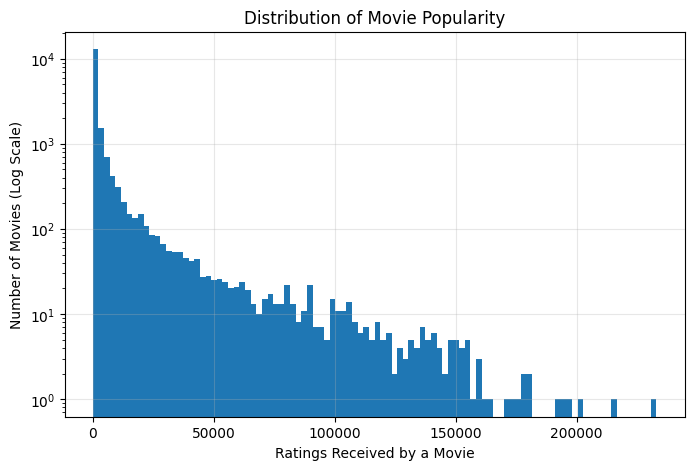

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    movie_ratings,
    bins=100,
    log=True
)

plt.title(
    "Distribution of Movie Popularity"
)

plt.xlabel(
    "Ratings Received by a Movie"
)

plt.ylabel(
    "Number of Movies (Log Scale)"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
print("Least Rated Movie :", movie_ratings.min())
print("Median Movie      :", np.median(movie_ratings))
print("Most Rated Movie  :", movie_ratings.max())

Least Rated Movie : 3
Median Movie      : 561.0
Most Rated Movie  : 232944


Observation - Movie popularity is highly uneven, with a small number of movies receiving substantially more ratings than the majority.

SECTION 5

Long Tail Structure (Understanding popularity concentration)

Does a small fraction of movies account for most user interactions?

In [ ]:
sorted_movies = np.sort(
    movie_ratings
)[::-1]

cumulative = np.cumsum(
    sorted_movies
)

cumulative = (
    cumulative /
    cumulative[-1]
)

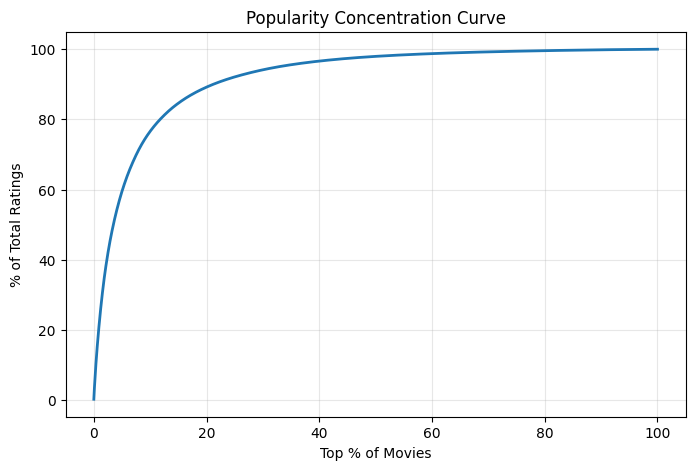

In [ ]:
movie_percent = (
    np.arange(
        1,
        len(sorted_movies) + 1
    )
    /
    len(sorted_movies)
) * 100

plt.figure(figsize=(8,5))

plt.plot(
    movie_percent,
    cumulative * 100,
    linewidth=2
)

plt.title(
    "Popularity Concentration Curve"
)

plt.xlabel(
    "Top % of Movies"
)

plt.ylabel(
    "% of Total Ratings"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
for pct in [1,5,10]:

    top_n = int(
        len(sorted_movies)
        * pct / 100
    )

    share = (
        sorted_movies[:top_n].sum()
        /
        sorted_movies.sum()
    )

    print(
        f"Top {pct}% movies:",
        f"{share:.2%}"
    )

Top 1% movies: 22.39%
Top 5% movies: 59.48%
Top 10% movies: 76.60%


Observation - A relatively small fraction of movies contributes a disproportionately large share of all ratings.

SECTION 6

Popularity Bias (Identifying the most dominant movies)

Which movies dominate user attention?

In [ ]:
movies = []

with open(
    "movie_titles.csv",
    "r",
    encoding="latin1"
) as f:

    for line in f:

        parts = line.strip().split(",", 2)

        movie_id = int(parts[0])

        try:
            year = int(parts[1])

        except:
            year = np.nan

        title = parts[2]

        movies.append([
            movie_id,
            year,
            title
        ])

movies = pd.DataFrame(
    movies,
    columns=[
        "movie_id",
        "year",
        "title"
    ]
)

movies.head()

,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [ ]:
top_movies = pd.DataFrame({
    "movie_id":
    list(movie_counts.keys()),

    "ratings":
    list(movie_counts.values())
})

In [ ]:
top_movies = top_movies.merge(
    movies,
    on="movie_id",
    how="left"
)

In [ ]:
top_movies = (
    top_movies
    .sort_values(
        "ratings",
        ascending=False
    )
)

top_movies.head(20)

,movie_id,ratings,year,title
5316,5317,232944,2000.0,Miss Congeniality
15123,15124,216596,1996.0,Independence Day
14312,14313,200832,2000.0,The Patriot
15204,15205,196397,2004.0,The Day After Tomorrow
1904,1905,193941,2003.0,Pirates of the Caribbean: The Curse of the Bla...
6286,6287,193295,1990.0,Pretty Woman
11282,11283,181508,1994.0,Forrest Gump
16376,16377,181426,1999.0,The Green Mile
16241,16242,178068,1997.0,Con Air
12469,12470,177556,1996.0,Twister


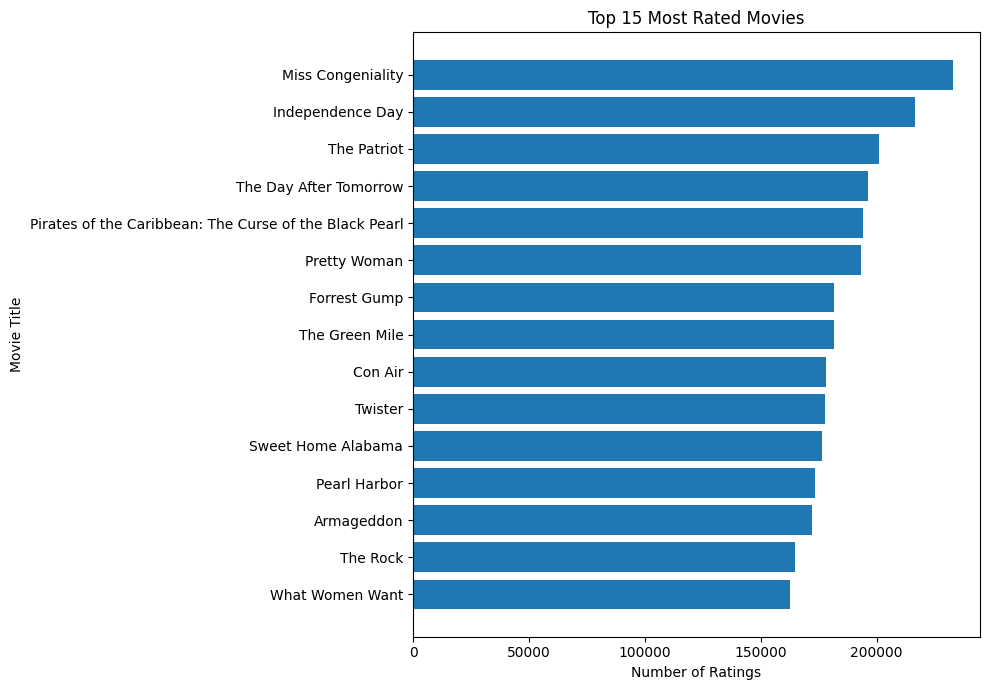

In [ ]:
top15_movies = top_movies.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top15_movies["title"][::-1],
    top15_movies["ratings"][::-1]
)

plt.title(
    "Top 15 Most Rated Movies"
)

plt.xlabel(
    "Number of Ratings"
)

plt.ylabel(
    "Movie Title"
)

plt.tight_layout()

plt.show()

Observation - A small number of blockbuster titles attract a disproportionately large volume of user interactions.

SECTION 7

Temporal Dynamics (Understanding how user activity changes over time)

How does rating activity evolve over time?

In [ ]:
from collections import Counter

year_counts = Counter()

for file in files:

    with open(file, "r") as f:

        for line in tqdm(
            f,
            desc=file
        ):

            line = line.strip()

            if line.endswith(":"):
                continue

            year = int(
                line.split(",")[2][:4]
            )

            year_counts[year] += 1

combined_data_1.txt: 24058263it [00:36, 665996.17it/s]
combined_data_2.txt: 26982302it [00:44, 606423.07it/s]
combined_data_3.txt: 22605786it [00:36, 621462.02it/s]
combined_data_4.txt: 26851926it [00:41, 645426.60it/s]


In [ ]:
year_df = pd.DataFrame({
    "year": sorted(
        year_counts.keys()
    ),

    "ratings": [
        year_counts[y]
        for y in sorted(
            year_counts.keys()
        )
    ]
})

year_df

,year,ratings
0,1999,2178
1,2000,924443
2,2001,1769031
3,2002,4342871
4,2003,9985337
5,2004,30206574
6,2005,53250073


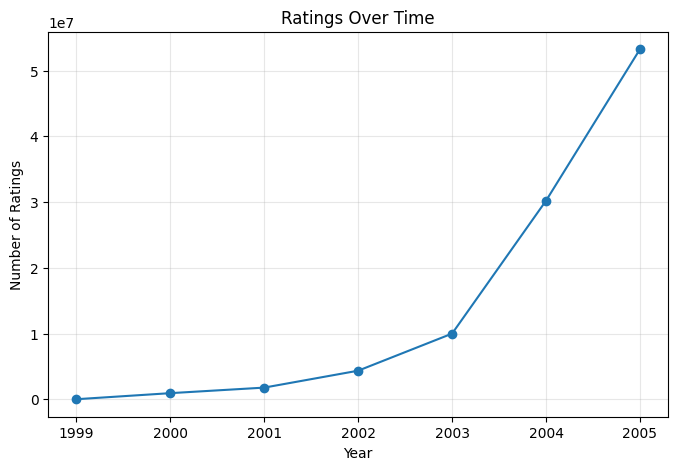

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    year_df["year"],
    year_df["ratings"],
    marker="o"
)

plt.title(
    "Ratings Over Time"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Number of Ratings"
)

plt.grid(alpha=0.3)

plt.show()

Observation - Rating activity changes considerably over time, indicating that temporal effects may play an important role in user behaviour.

SECTION 8

Average Ratings Over Time (Checking for temporal rating shifts)

Does the average rating change over time?

In [ ]:
year_sum = Counter()
year_count = Counter()

for file in files:

    with open(file, "r") as f:

        for line in tqdm(
            f,
            desc=file
        ):

            line = line.strip()

            if line.endswith(":"):
                continue

            parts = line.split(",")

            rating = int(parts[1])

            year = int(
                parts[2][:4]
            )

            year_sum[year] += rating
            year_count[year] += 1

combined_data_1.txt: 24058263it [00:56, 425470.43it/s]
combined_data_2.txt: 26982302it [01:03, 425279.83it/s]
combined_data_3.txt: 22605786it [00:50, 446458.67it/s]
combined_data_4.txt: 26851926it [01:00, 444911.66it/s]


In [ ]:
avg_rating_df = pd.DataFrame({
    "year": sorted(
        year_sum.keys()
    ),

    "avg_rating": [
        year_sum[y] /
        year_count[y]
        for y in sorted(
            year_sum.keys()
        )
    ]
})

avg_rating_df

,year,avg_rating
0,1999,3.337006
1,2000,3.365216
2,2001,3.390736
3,2002,3.381816
4,2003,3.406285
5,2004,3.594968
6,2005,3.676107


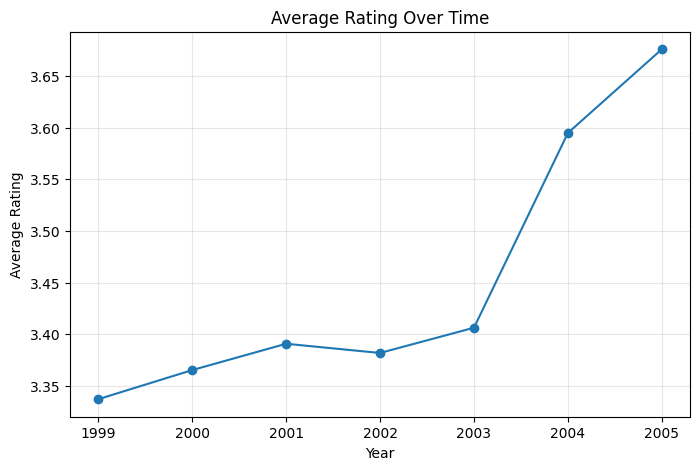

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    avg_rating_df["year"],
    avg_rating_df["avg_rating"],
    marker="o"
)

plt.title(
    "Average Rating Over Time"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Average Rating"
)

plt.grid(alpha=0.3)

plt.show()

Average ratings vary across years, suggesting that rating behaviour may not be stationary over time.

SECTION 8

User Bias Drift (Investigating whether users change behaviour over time)

Do highly active users change their rating behaviour over time?

In [ ]:
top_users = sorted(
    user_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:100]

In [ ]:
top_user_ids = set(
    [u[0] for u in top_users]
)

In [ ]:
user_year_sum = defaultdict(int)
user_year_count = defaultdict(int)

for file in files:

    with open(file, "r") as f:

        for line in tqdm(
            f,
            desc=file
        ):

            line = line.strip()

            if line.endswith(":"):
                continue

            user_id, rating, date = (
                line.split(",")
            )

            user_id = int(user_id)

            if user_id not in top_user_ids:
                continue

            year = int(
                date[:4]
            )

            rating = int(rating)

            user_year_sum[
                (user_id, year)
            ] += rating

            user_year_count[
                (user_id, year)
            ] += 1

combined_data_1.txt: 24058263it [00:37, 637470.03it/s]
combined_data_2.txt: 26982302it [00:38, 695026.64it/s]
combined_data_3.txt: 22605786it [00:29, 766383.39it/s]
combined_data_4.txt: 26851926it [00:34, 769592.62it/s]


In [ ]:
user_year_avg = []

for key in user_year_sum:

    user_id, year = key

    avg_rating = (
        user_year_sum[key]
        /
        user_year_count[key]
    )

    user_year_avg.append([
        user_id,
        year,
        avg_rating
    ])

user_year_avg = pd.DataFrame(
    user_year_avg,
    columns=[
        "user_id",
        "year",
        "avg_rating"
    ]
)

user_year_avg.head()

,user_id,year,avg_rating
0,1227322,2004,2.591463
1,786312,2004,2.945884
2,525356,2004,2.164549
3,1927580,2004,2.958066
4,1792741,2004,2.471197


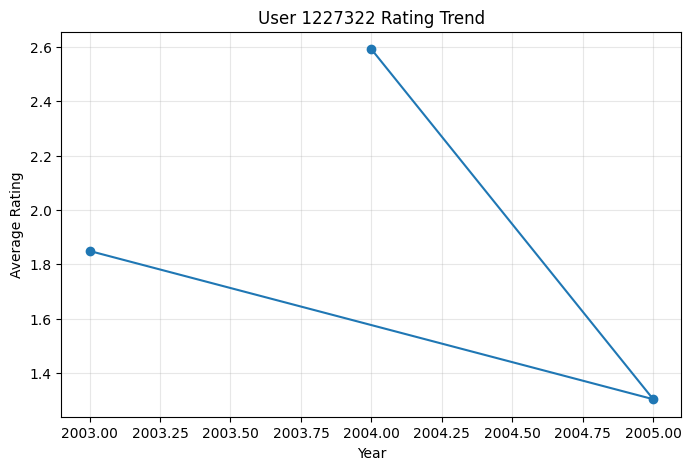

In [ ]:
sample_user = (
    user_year_avg["user_id"]
    .iloc[0]
)

temp = user_year_avg[
    user_year_avg["user_id"]
    == sample_user
]

plt.figure(figsize=(8,5))

plt.plot(
    temp["year"],
    temp["avg_rating"],
    marker="o"
)

plt.title(
    f"User {sample_user} Rating Trend"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Average Rating"
)

plt.grid(alpha=0.3)

plt.show()

Observation - Some users exhibit noticeable changes in average rating behaviour over time, suggesting the presence of user preference drift.

SECTION 8

User Bias Drift (Investigating changes in user rating behaviour over time)

Do highly active users change their rating behaviour over time?

In [ ]:
#Select Active Users
top_users = sorted(
    user_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:100]

In [ ]:
#Extract User IDs
top_user_ids = set(
    user_id
    for user_id, _
    in top_users
)

print(
    "Selected Users:",
    len(top_user_ids)
)

In [ ]:
#Collect User-Year Statistics
from collections import defaultdict

user_year_sum = defaultdict(float)
user_year_count = defaultdict(int)

for file in files:

    with open(file, "r") as f:

        for line in tqdm(
            f,
            desc=file
        ):

            line = line.strip()

            if line.endswith(":"):
                continue

            user_id, rating, date = (
                line.split(",")
            )

            user_id = int(user_id)

            if user_id not in top_user_ids:
                continue

            rating = int(rating)

            year = int(
                date[:4]
            )

            user_year_sum[
                (user_id, year)
            ] += rating

            user_year_count[
                (user_id, year)
            ] += 1

In [ ]:
#Create User-Year DataFrame
user_year_avg = []

for key in user_year_sum:

    user_id, year = key

    avg_rating = (
        user_year_sum[key]
        /
        user_year_count[key]
    )

    user_year_avg.append([
        user_id,
        year,
        avg_rating
    ])

user_year_avg = pd.DataFrame(
    user_year_avg,
    columns=[
        "user_id",
        "year",
        "avg_rating"
    ]
)

user_year_avg.head()

In [ ]:
#Example User Trend
sample_user = (
    user_year_avg["user_id"]
    .iloc[0]
)

temp = user_year_avg[
    user_year_avg["user_id"]
    == sample_user
]

plt.figure(figsize=(8,5))

plt.plot(
    temp["year"],
    temp["avg_rating"],
    marker="o"
)

plt.title(
    f"User {sample_user} Rating Trend"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Average Rating"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
#Multiple User Trends
plt.figure(figsize=(10,6))

for user_id in list(top_user_ids)[:10]:

    temp = user_year_avg[
        user_year_avg["user_id"]
        == user_id
    ]

    plt.plot(
        temp["year"],
        temp["avg_rating"],
        alpha=0.7
    )

plt.title(
    "User Rating Trends"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Average Rating"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Drift Quantification
user_drift = []

for user_id in top_user_ids:

    temp = (
        user_year_avg[
            user_year_avg["user_id"]
            == user_id
        ]
        .sort_values("year")
    )

    if len(temp) < 2:
        continue

    drift = (
        temp["avg_rating"].iloc[-1]
        -
        temp["avg_rating"].iloc[0]
    )

    user_drift.append(
        drift
    )

user_drift = np.array(
    user_drift
)

print(
    "Average Drift:",
    round(
        user_drift.mean(),
        4
    )
)

print(
    "Positive Drift:",
    (
        user_drift > 0
    ).sum()
)

print(
    "Negative Drift:",
    (
        user_drift < 0
    ).sum()
)

In [ ]:
#Drift Distribution
plt.figure(figsize=(8,5))

plt.hist(
    user_drift,
    bins=20
)

plt.title(
    "User Preference Drift"
)

plt.xlabel(
    "Rating Change"
)

plt.ylabel(
    "Number of Users"
)

plt.grid(alpha=0.3)

plt.show()

Observation - Many active users exhibit noticeable changes in average rating behaviour over time, indicating the presence of user preference drift.